In [ ]:
# 1. Imports and Dataset Loading
import json
import random
import numpy as np
import nltk
from nltk.stem import PorterStemmer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
import os

# Try to download the resource. The 'try...except' block makes it robust.
try:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True) # Added to fix LookupError
except:
    # If the download fails for any reason, print an error message
    print("Could not download NLTK 'punkt' or 'punkt_tab' resource. Check internet connection.")

# Define sample intents data
intents_data = {
    "intents": [
        {
            "tag": "greeting",
            "patterns": ["Hi", "How are you", "Is anyone there?", "Hello", "Good day"],
            "responses": ["Hello!", "Good to see you again!", "Hi there, how can I help?"]
        },
        {
            "tag": "goodbye",
            "patterns": ["Bye", "See you later", "Goodbye", "Nice chatting to you, bye", "Till next time"],
            "responses": ["See you!", "Have a nice day", "Bye! Come back again soon."]
        },
        {
            "tag": "thanks",
            "patterns": ["Thanks", "Thank you", "That's helpful", "Thank's a lot"],
            "responses": ["Happy to help!", "Any time!", "My pleasure"]
        },
        {
            "tag": "name",
            "patterns": ["What is your name?", "Who are you?", "May I know your name?"],
            "responses": ["I am a chatbot created to assist you.", "You can call me Bot."]
        },
        {
            "tag": "age",
            "patterns": ["How old are you?", "What is your age?"],
            "responses": ["I don't have an age, I'm a program."]
        }
    ]
}

# Create intents.json if it doesn't exist
file_path = 'intents.json'
if not os.path.exists(file_path):
    with open(file_path, 'w') as f:
        json.dump(intents_data, f, indent=4)
    print(f"'{file_path}' created successfully with sample data.")
else:
    print(f"'{file_path}' already exists. Skipping creation.")

# Load the intents data from intents.json
try:
    with open('intents.json', 'r') as file:
        data = json.load(file)
    print("'intents.json' loaded successfully.")
except FileNotFoundError:
    print("Error: 'intents.json' not found. Please ensure it exists.")
    data = {'intents': []}
except json.JSONDecodeError:
    print("Error: Could not decode 'intents.json'. Please check its format.")
    data = {'intents': []}

'intents.json' already exists. Skipping creation.
'intents.json' loaded successfully.


In [ ]:
# 2. Data Preprocessing, Bag-of-Words, and Label Encoding

stemmer = PorterStemmer()

def tokenize_and_stem(text):
    return [stemmer.stem(w.lower()) for w in word_tokenize(text)]

words = []
X = []
y = []

if 'intents' in data and data['intents']:
    for intent in data['intents']:
        tag = intent['tag']

        for pattern in intent['patterns']:
            tokenized = tokenize_and_stem(pattern)

            words.extend(tokenized)

            X.append(tokenized)
            y.append(tag)

    words = sorted(list(set(words)))

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    print("Data preprocessing complete.")
else:
    print("No intents found in 'data'. Skipping preprocessing.")
    # Initialize empty variables to prevent errors if no data was loaded
    words = []
    X = []
    y = []
    y_encoded = np.array([])
    label_encoder = LabelEncoder()


def bag_of_words(tokenized_sentence):
    bag = np.zeros(len(words))

    for w_stemmed in tokenized_sentence:
        if w_stemmed in words:
            bag[words.index(w_stemmed)] = 1
    return bag

# Apply the function to create the bag of words matrix
x_bow = np.array([bag_of_words(sentence) for sentence in X])

# Convert the encoded labels to a numpy array
y_final = np.array(y_encoded)

from sklearn.model_selection import train_test_split

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_bow, y_final, test_size=0.25, random_state=42, stratify=y_final)

print(f"Training samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")

Data preprocessing complete.
Training samples: 14
Test samples: 5


In [ ]:
# 3. Model Building and Training Setup

# Ensure necessary Keras components are imported
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization # Added BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

if len(words) > 0 and len(np.unique(y)) > 0:
    # Define the input layer shape based on the vocabulary size
    input_shape = (len(words),)

    # Model Definition (Modified for potentially better accuracy)
    model = Sequential()
    model.add(Input(shape=input_shape))
    # First hidden layer: increased neurons, added BatchNormalization
    model.add(Dense(256, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.3)) # Adjusted dropout rate

    # Second hidden layer: slightly increased neurons
    model.add(Dense(128, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.2)) # Adjusted dropout rate

    # Third hidden layer (newly added)
    model.add(Dense(64, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Output layer: The number of neurons equals the number of unique tags (classes)
    # Softmax activation is used for multi-class probability distribution output
    model.add(Dense(len(np.unique(y)), activation="softmax"))

    # Model Compilation
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Define a callback for Early Stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True) # Increased patience and added restore_best_weights

    model.summary()
    print("Model built and compiled successfully with architectural improvements.")
else:
    print("Cannot build model: Not enough unique words or intents after preprocessing.")
    # Create a dummy model to prevent errors in subsequent cells if model cannot be built
    model = None # Or a very basic placeholder if needed later

# 4. Model Training (Add this step if not already present, it's crucial for evaluation)

if model and len(x_train) > 0 and len(y_train) > 0:
    print("Starting model training...")
    # Use x_train and y_train for training, and x_test and y_test for validation
    history = model.fit(x_train, y_train, epochs=200, batch_size=5, verbose=1, callbacks=[early_stopping], validation_data=(x_test, y_test))
    print("Model training complete.")
else:
    print("Cannot train model: Model not built or data (x_train, y_train) is empty.")

# 5. Evaluation

if model and len(x_test) > 0 and len(y_test) > 0:
    print("Performing model evaluation on test set...")
    y_probs_test = model.predict(x_test)
    y_pred_test = np.argmax(y_probs_test, axis=1)

    acc = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')

    print(f"Accuracy on test set: {acc:.4f}")
    print(f"F1-score (weighted) on test set: {f1:.4f}")
    print("\nClassification report on test set:")
    print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_, zero_division=0))
else:
    print("Cannot evaluate model: Model not built or test data (x_test, y_test) is empty.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,997 (207.02 KB)

 Trainable params: 52,101 (203.52 KB)

 Non-trainable params: 896 (3.50 KB)

Model built and compiled successfully with architectural improvements.
Starting model training...
Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 416ms/step - accuracy: 0.0000e+00 - loss: 3.1649 - val_accuracy: 0.4000 - val_loss: 1.6022
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1214 - loss: 2.0181 - val_accuracy: 0.4000 - val_loss: 1.5984
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4393 - loss: 1.3231 - val_accuracy: 0.2000 - val_loss: 1.5917
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4036 - loss: 1.7255 - val_accuracy: 0.4000 - val_loss: 1.5856
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5107 - loss: 1.1894 - val_accuracy: 0.4000 - val_loss: 1.5795
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3286 - loss: 1.5394 - val_accuracy: 0.4000 - val_loss: 1.5769
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3643 - loss: 1.2729 - val_accuracy: 0.4000 - val_loss: 1.5747
Epoch 8/200
3/3

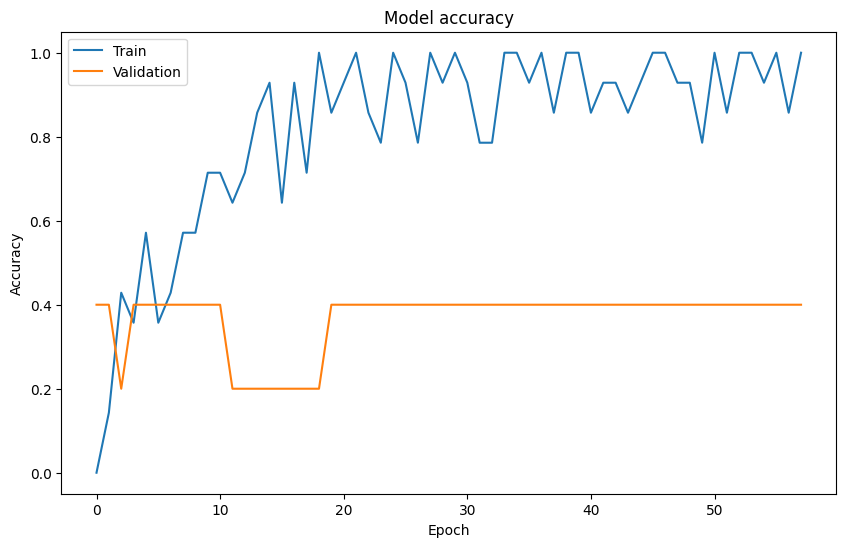

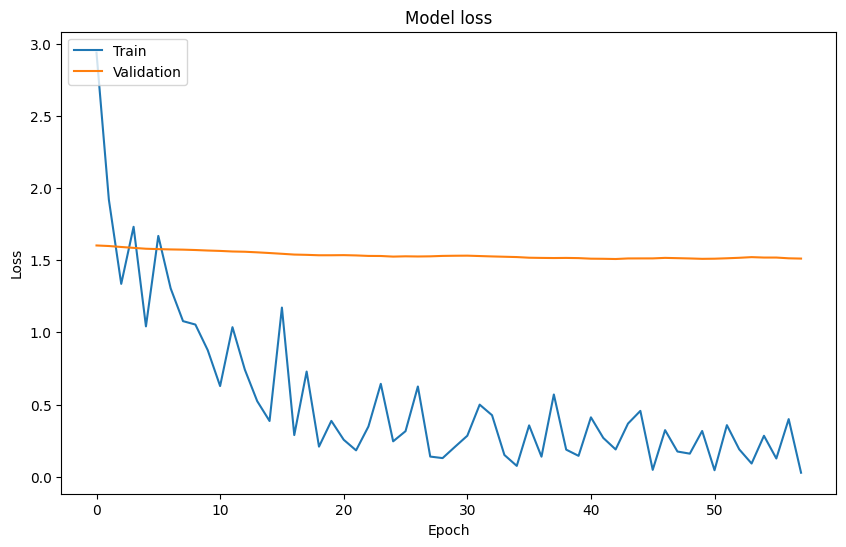

In [ ]:
import matplotlib.pyplot as plt
#accuracy code

if 'history' in locals() and history is not None:
    # Plot training & validation accuracy values
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

    # Plot training & validation loss values
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()
else:
    print("Model training history not found. Please ensure the model was trained successfully.")

In [ ]:
# 3. Model Building and Training Setup

# Ensure necessary Keras components are imported
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization # Added BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

if len(words) > 0 and len(np.unique(y)) > 0:
    # Define the input layer shape based on the vocabulary size
    input_shape = (len(words),)

    # Model Definition (Modified for potentially better accuracy)
    model = Sequential()
    model.add(Input(shape=input_shape))
    # First hidden layer: increased neurons, added BatchNormalization
    model.add(Dense(256, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.3)) # Adjusted dropout rate

    # Second hidden layer: slightly increased neurons
    model.add(Dense(128, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.2)) # Adjusted dropout rate

    # Third hidden layer (newly added)
    model.add(Dense(64, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Output layer: The number of neurons equals the number of unique tags (classes)
    # Softmax activation is used for multi-class probability distribution output
    model.add(Dense(len(np.unique(y)), activation="softmax"))

    # Model Compilation
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Define a callback for Early Stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True) # Increased patience and added restore_best_weights

    model.summary()
    print("Model built and compiled successfully with architectural improvements.")
else:
    print("Cannot build model: Not enough unique words or intents after preprocessing.")
    # Create a dummy model to prevent errors in subsequent cells if model cannot be built
    model = None # Or a very basic placeholder if needed later

# 4. Model Training (Add this step if not already present, it's crucial for evaluation)

if model and len(x_train) > 0 and len(y_train) > 0:
    print("Starting model training...")
    # Use x_train and y_train for training, and x_test and y_test for validation
    history = model.fit(x_train, y_train, epochs=200, batch_size=5, verbose=1, callbacks=[early_stopping], validation_data=(x_test, y_test))
    print("Model training complete.")
else:
    print("Cannot train model: Model not built or data (x_train, y_train) is empty.")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,997 (207.02 KB)

 Trainable params: 52,101 (203.52 KB)

 Non-trainable params: 896 (3.50 KB)

Model built and compiled successfully with architectural improvements.
Starting model training...
Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.1714 - loss: 2.6803 - val_accuracy: 0.0000e+00 - val_loss: 1.6162
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3536 - loss: 2.4103 - val_accuracy: 0.0000e+00 - val_loss: 1.6142
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4500 - loss: 1.8473 - val_accuracy: 0.0000e+00 - val_loss: 1.6110
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5750 - loss: 1.5745 - val_accuracy: 0.2000 - val_loss: 1.6080
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4643 - loss: 1.7130 - val_accuracy: 0.2000 - val_loss: 1.6039
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5464 - loss: 1.0723 - val_accuracy: 0.2000 - val_loss: 1.6014
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6464 - loss: 0.9678 - val_accuracy: 0.2000 - val_loss: 1.5975
Epoch 8

In [ ]:
# 5. Evaluation

if model and len(x_test) > 0 and len(y_test) > 0:
    print("Performing model evaluation on test set...")
    y_probs_test = model.predict(x_test)
    y_pred_test = np.argmax(y_probs_test, axis=1)

    acc = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')

    print(f"Accuracy on test set: {acc:.4f}")
    print(f"F1-score (weighted) on test set: {f1:.4f}")
    print("\nClassification report on test set:")
    print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_, zero_division=0))
else:
    print("Cannot evaluate model: Model not built or test data (x_test, y_test) is empty.")

Performing model evaluation on test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Accuracy on test set: 0.2000
F1-score (weighted) on test set: 0.1333

Classification report on test set:
              precision    recall  f1-score   support

         age       0.00      0.00      0.00         1
     goodbye       0.00      0.00      0.00         1
    greeting       0.00      0.00      0.00         1
        name       0.50      1.00      0.67         1
      thanks       0.00      0.00      0.00         1

    accuracy                           0.20         5
   macro avg       0.10      0.20      0.13         5
weighted avg       0.10      0.20      0.13         5



In [ ]:
# 6. Chat Function (Retrieval-based Responses)
def predict_class(sentence):
  if not words or not label_encoder or not model:
      print("Chatbot not fully initialized. Please ensure all previous steps ran successfully.")
      return "unknown"
  tokens = tokenize_and_stem(sentence)
  bow = bag_of_words(tokens)
  # Reshape for single prediction
  results = model.predict(np.array([bow]), verbose=0)[0]
  # Check if results contain valid probabilities
  if not results.any():
      return "unknown"
  idx = np.argmax(results)
  return label_encoder.inverse_transform([idx])[0]

def get_response(tag):
    for intent in data['intents']:
        if intent['tag'] == tag:
            return random.choice(intent['responses'])
    return "Sorry, I didn't understand that."

def chat():
    print("Chatbot is ready! (type 'quit' to exit)")
    while True:
        msg = input("You: ")
        if msg.lower() == 'quit':
            break

        intent = predict_class(msg)
        response = get_response(intent)

        print("Bot:", response)

# Run the chat function
if model and len(words) > 0:
    chat()
else:
    print("Chatbot cannot start. Model not built or vocabulary is empty.")

Chatbot is ready! (type 'quit' to exit)
Bot: Hi there, how can I help?
Bot: See you!
